<div style="text-align: center;">
<h1> Testing multiROMA with GSVD </h1>    
</div>

This notebook is meant as a first tutorial to get started with GSVD-multiROMA. It runs based on the CPTAC-BRCA dataset, that can be found and download [here](url.to.add). Additionally, please ensure multiroma is installed, as well as all dependecies, before proceeeding. 

### Importing the necessary data and modules

In this first part, let us import all necessary data and modules. The gmt file specifying the gene sets is referenced with the dataset: the vignette to generate the gmt from the raw BRCA dataset is presented in the "BRCA_preprocessing" notebook. It is an extension from pre-existing MSigDB Hallmark Dataset referenced [here](url.to.add).  \
A FutureWarning can appear, as the mudata module is not synchronised with the latest robust scanpy version as of yet. 

In [1]:
# Imports
from multiroma_ import multiroma 
from multiroma_.plotting import plotting_L1_distribution, plotting_clustermap, PC_samples_projection_GSVD, Gene_score_projections, plotting_L1_distribution_per_set
import mudata
mudata.set_options(pull_on_update=False)
import muon as mu
import os
import zipfile
import io
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.io
from glob import glob
import time

/opt/anaconda3/envs/ROMA_proj/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
import sys
sys.path.insert(0, "/Users/lucie-garance/pygsvd")
import pygsvd 

Let us start by initialising a ROMA class object. This class object will then integrate all input and results. 

In [3]:
# Initialising ROMA class object
roma = multiroma.ROMA_GSVD()
roma

scROMA

In [4]:
mudata=mu.read("datasets/BRCA/combined_BRCA_dataset_rna_and_prot_preprocessed.h5mu")
mudata

MuData object with n_obs × n_vars = 121 × 28722
  2 modalities
    rna:	121 x 16708
      obs:	'celltype'
    prot:	121 x 12014
      obs:	'celltype'

### Running MultiROMA GSVD

After pre-processing of the dataset, and recovery of the proper object, let us proceed with the multiROMA analysis. \
Warning: over 100 iterations, this code is quite long to run. Consider running it on a remote cluster instead of your personal computer.

In [5]:
# Retrieving the path to the .gmt file containing the gene sets
roma.gmt = "genesets/BRCA_h.all.v2023.1.Hs.symbols_expanded.gmt"  #specifying the path

roma.pc_sign_mode = 'UseMeanExpressionAllWeights'      #defining the method to orient PC1 (orienting with signs)
pathways_to_check = 'all' 
iters=3                                                #number of iterations – default (recommanded) is 500

After specifying all important parameters, multiROMA analysis is performed using the compute() function. This function only supports multiomic analysis. \
For a lighter calling in the case of a multiomic analysis, suffice to specify mudata and selected_gene_sets – all other parameters have default values.

In [6]:
start = time.time()                                    #loop to determine the duration of run

roma.compute(selected_gene_sets=pathways_to_check,  #gene set selection
        mudata=mudata,
        parallel = True,                      #parallel processing for null distribution determination
        iters = iters,                        #nb of iterations
        loocv_on = True,                      #leave-one-out cross validation for outliers detection (else, what happens?)
        double_mean_centering = False,        #center data over samples and genes
        outlier_fisher_thr = 0.05,            #pval threshold for getting rid of outliers (fisher test)
        min_gene_sets = 3,                    #minimum number of gene sets a gene has to appear in to be considered for outlier removal (we don't remove rare genes)
        max_outlier_prop = 0.5,               #maximum proportion of outliers that can be removed in a gene set (we don't remove all genes)
        verbose = 0)                          #verbose or not verbose, that is the question

end = time.time()

minutes, seconds = divmod(end - start, 60) 

print(f"Ran in {minutes}min and {seconds}seconds") 

Processing gene set: HALLMARK_PANCREAS_BETA_CELLS | len of subsetlist: 47 


/opt/anaconda3/envs/ROMA_proj/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/opt/anaconda3/envs/ROMA_proj/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):
/opt/anaconda3/envs/ROMA_proj/lib/python3.11/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


Processing gene set: HALLMARK_NOTCH_SIGNALING | len of subsetlist: 58 
Processing gene set: HALLMARK_HEDGEHOG_SIGNALING | len of subsetlist: 62 
Processing gene set: HALLMARK_ANGIOGENESIS | len of subsetlist: 65 
Processing gene set: HALLMARK_WNT_BETA_CATENIN_SIGNALING | len of subsetlist: 73 
Processing gene set: HALLMARK_APICAL_SURFACE | len of subsetlist: 76 
Processing gene set: HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY | len of subsetlist: 88 
Processing gene set: HALLMARK_TGF_BETA_SIGNALING | len of subsetlist: 100 
Processing gene set: HALLMARK_MYC_TARGETS_V2 | len of subsetlist: 112 
Processing gene set: HALLMARK_CHOLESTEROL_HOMEOSTASIS | len of subsetlist: 138 
Processing gene set: HALLMARK_IL6_JAK_STAT3_SIGNALING | len of subsetlist: 141 
Processing gene set: HALLMARK_INTERFERON_ALPHA_RESPONSE | len of subsetlist: 185 
Processing gene set: HALLMARK_SPERMATOGENESIS | len of subsetlist: 185 
Processing gene set: HALLMARK_BILE_ACID_METABOLISM | len of subsetlist: 186 
Processing 

### Output and analyses

After multiROMA has run, it outputs an AnnData object containing all the results. These can be extracted in the form of multiple dataframes containing the statistics for all and for the active pathways identified. Additionnaly, a plotting module allows to monitor the L1 null distribution, as well as the structuration of pathways scores and a cleaveland plot for top gene selection. \
The roma.adata object is presented below. In this object can be found all the scores for the different modules. In multiROMA-MFA, two scores are displayed: the L1 score, quantifying the dispersion of values in each gene set, and the Median Expression, quantifying the expression of genes in each gene set. Both scores are confronted to a null distribution, made from the scoring of multiple gene set of similar size than the target but randomly selected. This procedure allows to identify the active and inactive pathways among those tested.

In [7]:
roma.adata

AnnData object with n_obs × n_vars = 121 × 28722
    obs: 'rna:celltype', 'prot:celltype'
    var: 'modality'

For a first sanity check, it is possible to plot the null L1 distributions. Each L1 distribution corresponds to a gene set sizing determined by the size of the batches generated during parallelisation. \
One can expect a distribution shifted towards zero, with very few values over 0.4, and only represented in the smallest gene set sizes.

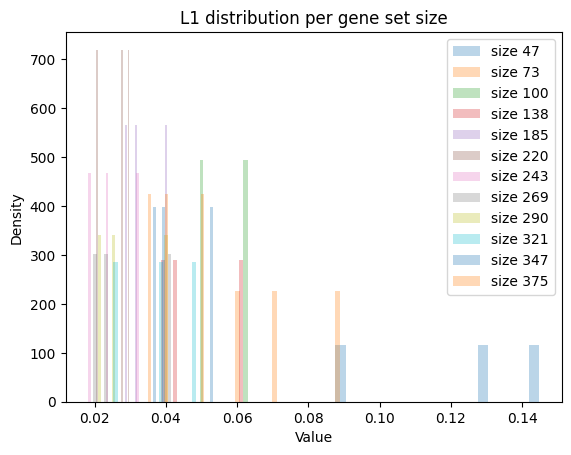

In [8]:
plotting_L1_distribution(roma.null_distributions)

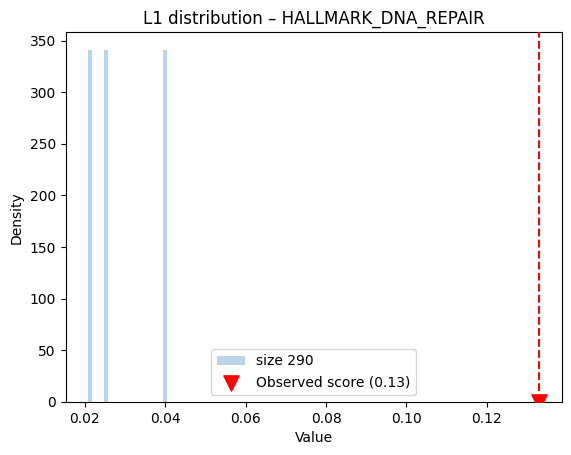

In [9]:
plotting_L1_distribution_per_set(roma.mudata, roma.null_distributions, "HALLMARK_DNA_REPAIR")

After a sanity check, one can start analysis by taking a look at the summary of the analysis. This summary details the number or overdispersed and shifted modules (warning: a single module can be both overdispersed and shifted), as well as the top ten of each category of modules. This top 5 is not taking in consideration the q-value threshold: therefore, some modules in the top 5 can be inactive. 

In [10]:
roma.summary() 


=== ROMA Analysis Summary ===

Total gene sets analyzed: 50
Active modules (overdispersed): 27
Active modules (shifted in rna): 0
Active modules (shifted in prot): 0

Top 5 overdispersed modules:
  HALLMARK_TGF_BETA_SIGNALING: L1=0.087, q=0.000e+00
  HALLMARK_MYC_TARGETS_V2: L1=0.102, q=0.000e+00
  HALLMARK_INTERFERON_ALPHA_RESPONSE: L1=0.125, q=0.000e+00
  HALLMARK_UV_RESPONSE_DN: L1=0.080, q=0.000e+00
  HALLMARK_APOPTOSIS: L1=0.058, q=0.000e+00

Top 5 shifted modules for rna :
  HALLMARK_PANCREAS_BETA_CELLS: Med=-11.906, q=3.289e-01
  HALLMARK_NOTCH_SIGNALING: Med=-5.922, q=3.289e-01
  HALLMARK_ANGIOGENESIS: Med=28.017, q=3.289e-01
  HALLMARK_MYC_TARGETS_V2: Med=-57.205, q=3.289e-01
  HALLMARK_CHOLESTEROL_HOMEOSTASIS: Med=17.518, q=3.289e-01

Top 5 shifted modules for prot :
  HALLMARK_PANCREAS_BETA_CELLS: Med=-14.428, q=4.167e-01
  HALLMARK_HEDGEHOG_SIGNALING: Med=5.900, q=4.167e-01
  HALLMARK_ANGIOGENESIS: Med=26.209, q=4.167e-01
  HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY: Med=9.1

A list of active modules can be found in the roma.adata object. It presents as a dataset, displaying the L1 and Median Expression scores, with their respective p-values and q-values. 

In [11]:
# Looking at specifically active modules
roma.mudata.uns['ROMA_active_modules'] #.sort_values(by='Median Exp')

,L1,ppv L1,Median Exp rna,ppv Med Exp rna,Median Exp prot,ppv Med Exp prot,q L1,q Med Exp rna,q Med Exp prot
HALLMARK_TGF_BETA_SIGNALING,0.086516,0.0,2.683454,0.75,5.896534,0.50,0.0,0.765306,0.657895
HALLMARK_MYC_TARGETS_V2,0.101815,0.0,-57.205314,0.25,-46.970415,0.25,0.0,0.328947,0.416667
HALLMARK_INTERFERON_ALPHA_RESPONSE,0.124692,0.0,-124.741116,0.25,-70.494730,0.25,0.0,0.328947,0.416667
HALLMARK_UV_RESPONSE_DN,0.080399,0.0,-133.796975,0.25,-9.286216,0.50,0.0,0.328947,0.657895
HALLMARK_APOPTOSIS,0.057536,0.0,6.220617,0.50,-2.087952,0.75,0.0,0.581395,0.833333
HALLMARK_FATTY_ACID_METABOLISM,0.087302,0.0,-13.052419,0.25,-6.585024,0.75,0.0,0.328947,0.833333
HALLMARK_DNA_REPAIR,0.132953,0.0,-37.519621,0.25,-3.268533,0.75,0.0,0.328947,0.833333
HALLMARK_INFLAMMATORY_RESPONSE,0.059771,0.0,-229.776272,0.25,-10.665375,0.50,0.0,0.328947,0.657895
HALLMARK_HEME_METABOLISM,0.053307,0.0,3.801547,0.50,14.166713,0.50,0.0,0.581395,0.657895
HALLMARK_TNFA_SIGNALING_VIA_NFKB,0.123543,0.0,-254.420361,0.25,-14.087103,0.50,0.0,0.328947,0.657895


One can also display the statistics for all gene sets tested. 

In [12]:
## Looking at all the statistics per gene set 
#roma.adata.uns['ROMA_stats'] 

Below is presented a clustermap of the results, to try uncover the structuration of multiROMA scores for pathways. For this clustermap, we indicate as input a ground truth classification: here for example, we took the PAM50 classification, to try seeing if this classification could be recapitulated using our pathway activity scores. Then, another data-driven clustering is performed (by default a CAH clustering), and then both structurations are confronted to the heatmap of the scores for each active pathway and each sample. 

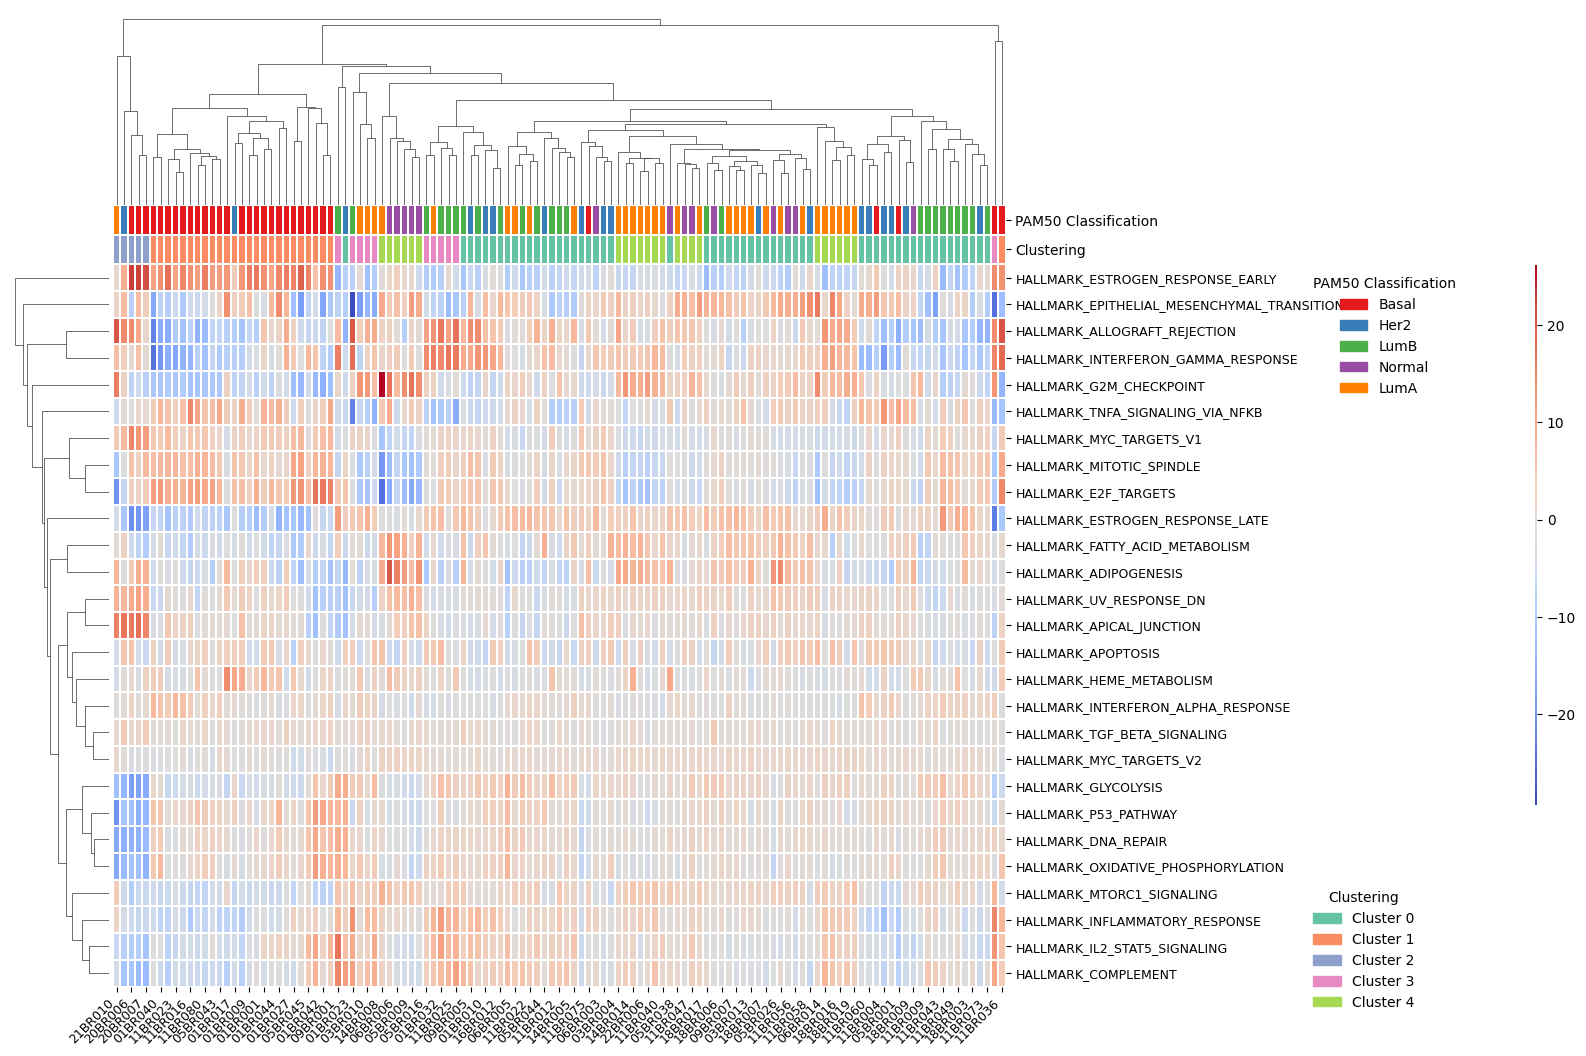

0.3885395346337424

In [13]:
pam50_classification=pd.read_csv("datasets/BRCA/pam50_clustering.csv", index_col=0)
pam_id=pam50_classification["PAM50_subtype"]
ground_truth={"PAM50 Classification":pam_id}
plotting_clustermap(roma.mudata, ground_truth=ground_truth)

In this next figure is presented the projection of the samples on the first PC axis for each pathway tested. This allows to have a more visual view of the activity and dispersion of the samples over all pathways. 

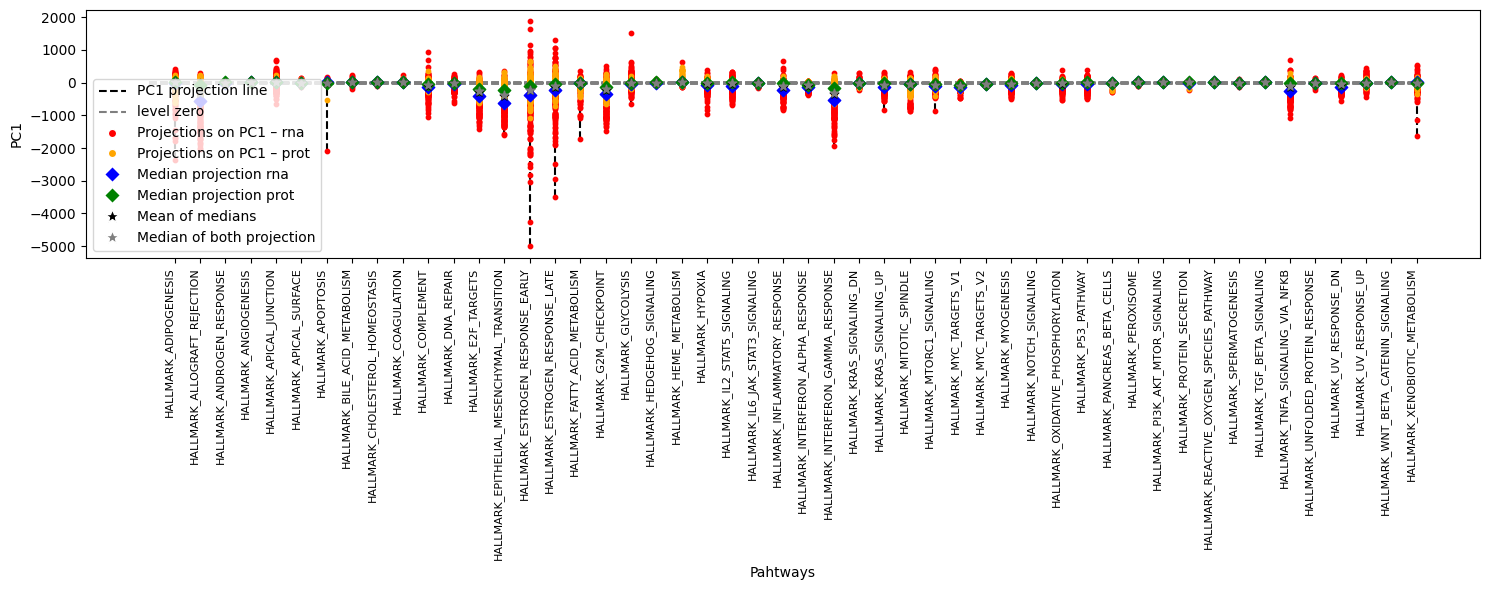

In [14]:
PC_samples_projection_GSVD(roma.mudata)

Finally, below is presented a cleveland plot displaying the scores of each gene of the specified pathways. This allows to identify the top contributing genes. Moreover, the genes are specifically labeled based on the omic they come from, making this information available as well. The "top" parameter allows to crop the graph to get only the top X contributing genes (by default, all genes are plotted). 

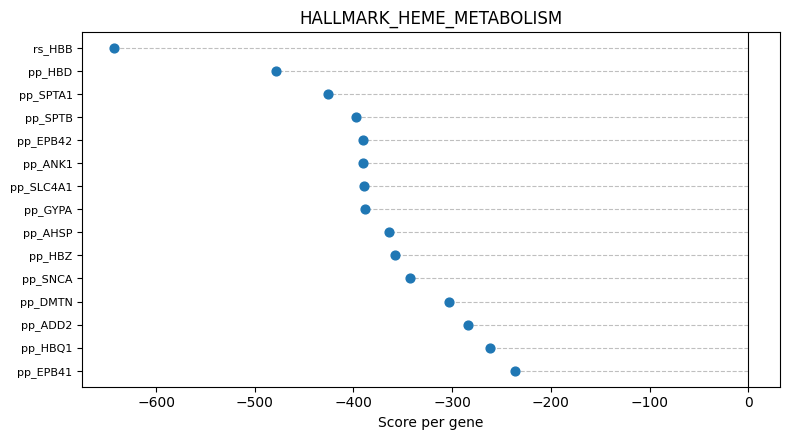

In [15]:
Gene_score_projections(roma, "HALLMARK_HEME_METABOLISM", top=15)